In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

2024-06-04 07:47:33.500676: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-04 07:47:34.709468: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-04 07:47:37.107835: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-04 07:47:41.116093: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [3]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,15000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [4]:



data = awgn(data, snr_range)

In [ ]:
print(data)

In [5]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)
augmented_sample = apply_random_noise(augmented_sample, noise_level)


In [6]:
data.shape

(15000, 8192)

/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


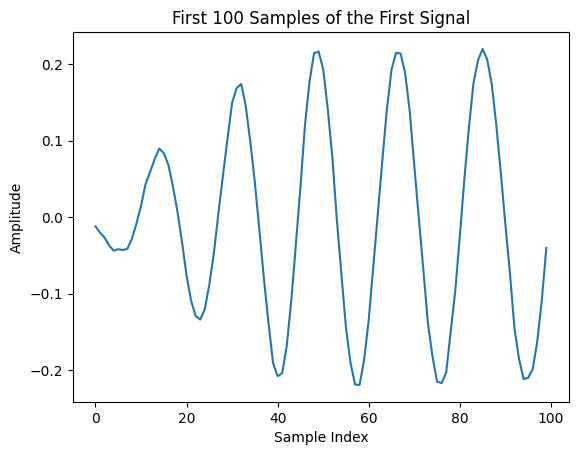

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = data # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

In [8]:
data.shape

(15000, 8192)

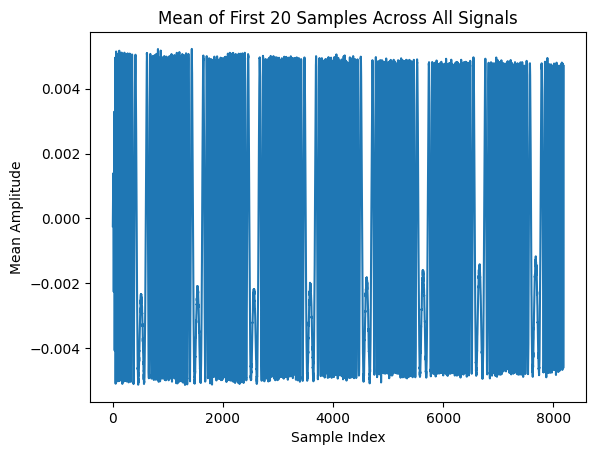

Suspected Preamble: [-2.42345082e-04+0.00063146j -2.66971165e-05+0.00068031j
  6.95640367e-05+0.00081932j ...  3.72039484e-03-0.00276909j
  4.46903852e-03-0.00140398j  4.70683071e-03-0.00028533j]


In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is a NumPy array with shape (30000, 8192)

# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 8192  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 20 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


In [50]:
data.shape

(15000, 8192)

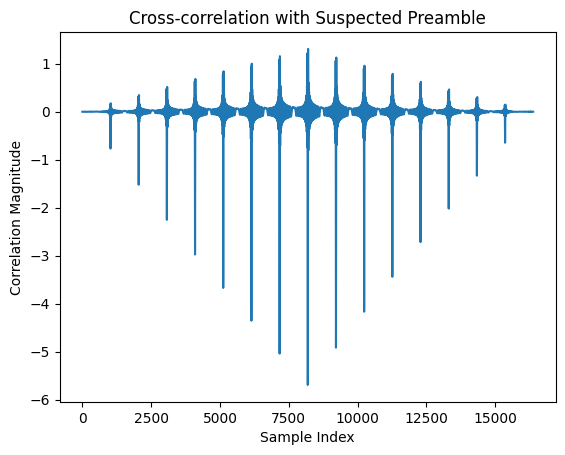

Peak correlation index: 8191
Peak correlation value: (-5.694027662667042+6.517043420146571j)
Synchronized signal start index: 0


In [51]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [52]:
data.shape

(15000, 8192)

In [54]:
data[0].shape

(8192,)

In [56]:
import numpy as np

# Given values
peak_index =8191
preamble_length = 8192  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [-0.01194916-0.01750561j -0.01997508-0.0201325j  -0.02651061-0.02234627j
 ... -0.01363192+0.21228734j -0.09079015+0.20469691j
 -0.13637796+0.16519128j]
Synchronized signal start index: 0


In [57]:
suspected_preamble

array([-0.01194916-0.01750561j, -0.01997508-0.0201325j ,
       -0.02651061-0.02234627j, ..., -0.01363192+0.21228734j,
       -0.09079015+0.20469691j, -0.13637796+0.16519128j])

In [60]:
preamble=suspected_preamble

In [59]:
preamble

In [37]:
received_signal


array([-0.01194916-0.01750561j, -0.01997508-0.0201325j ,
       -0.02651061-0.02234627j, ..., -0.01363192+0.21228734j,
       -0.09079015+0.20469691j, -0.13637796+0.16519128j])

In [38]:
preamble

array([-0.10207223+0.19352049j, -0.05452325+0.21446253j,
       -0.00903956+0.2211457j ,  0.04824519+0.21326276j,
        0.10228029+0.18931261j,  0.15494117+0.15711134j,
        0.1923988 +0.09929268j,  0.21637994+0.03692738j,
        0.21994862-0.03269766j,  0.19136155-0.1055519j ,
        0.15346947-0.16325916j,  0.08375267-0.19970045j,
        0.0147411 -0.22472639j, -0.06959881-0.20621809j,
       -0.13091758-0.17503802j, -0.18404407-0.12091939j,
       -0.21296205-0.04152435j, -0.21606234+0.02219327j,
       -0.19415887+0.10635839j, -0.13976857+0.17094931j])

In [41]:
# Reshape received signal to match the length of the preamble
received_signal_reshaped = np.tile(received_signal, (len(preamble) // len(received_signal) + 1))[:len(preamble)]


In [43]:
import numpy as np



         

#reshaped_signal = received_signal.reshape(preamble.shape)
reshaped_signal = received_signal_reshaped.reshape(preamble.shape)

print("Reshaped signal:", reshaped_signal)

Reshaped signal: [-0.01194916-0.01750561j -0.01997508-0.0201325j  -0.02651061-0.02234627j
 -0.03684317-0.01067999j -0.04361754+0.0012473j  -0.04174838+0.00784963j
 -0.04277702+0.02087386j -0.04134441+0.04050555j -0.02834507+0.04918682j
 -0.00848422+0.06532616j  0.01490246+0.06643517j  0.04323635+0.05579144j
  0.05931315+0.04768907j  0.07601616+0.02059831j  0.08964238-0.01144849j
  0.08404959-0.04499684j  0.06868526-0.06827878j  0.0409105 -0.09110415j
  0.00748053-0.10334145j -0.03217014-0.1101355j ]


In [35]:
preamble.shape

(20,)

In [45]:
received_signal=reshaped_signal

In [46]:
import numpy as np
from scipy.signal import correlate

def coarse_time_sync(received_signal, preamble):
    correlation = correlate(received_signal, preamble)
    start_index = np.argmax(np.abs(correlation))
    return start_index

def fine_time_sync(signal):
    # Placeholder for actual fine synchronization logic
    fine_sync_index = 0  # Update with fine synchronization technique
    return fine_sync_index

def estimate_cfo(received_signal, symbol_rate):
    phase_diffs = np.angle(received_signal[1:] * np.conj(received_signal[:-1]))
    cfo_estimate = np.mean(phase_diffs) / (2 * np.pi * symbol_rate)
    return cfo_estimate

def compensate_cfo(received_signal, cfo_estimate, symbol_rate):
    n = np.arange(len(received_signal))
    correction_signal = np.exp(-1j * 2 * np.pi * cfo_estimate * n / symbol_rate)
    cfo_compensated_signal = received_signal * correction_signal
    return cfo_compensated_signal

# Define your known preamble, received signal, and symbol rate
preamble = preamble  # Known preamble sequence
received_signal = received_signal  # Received signal, shape (2000, 8192)
symbol_rate = 1  # Symbol rate of your communication system

# Initialize the output array
compensated_signals = np.zeros_like(received_signal, dtype=complex)

# Process each signal sequence independently
for i in range(received_signal.shape[0]):
    # Coarse Time Synchronization
    start_index = coarse_time_sync(received_signal[i], preamble)
    synchronized_signal = received_signal[i, start_index:]
    
    # Fine Time Synchronization
    fine_sync_index = fine_time_sync(synchronized_signal)
    fine_synchronized_signal = synchronized_signal[fine_sync_index:]
    
    # CFO Estimation
    cfo_estimate = estimate_cfo(fine_synchronized_signal, symbol_rate)
    
    # CFO Compensation
    cfo_compensated_signal = compensate_cfo(fine_synchronized_signal, cfo_estimate, symbol_rate)
    
    # Ensure the length matches the original signal length, pad or truncate as needed
    if len(cfo_compensated_signal) < received_signal.shape[1]:
        compensated_signals[i, :len(cfo_compensated_signal)] = cfo_compensated_signal
    else:
        compensated_signals[i] = cfo_compensated_signal[:received_signal.shape[1]]

# Now, compensated_signals should have the same shape as the original received_signal
print(compensated_signals.shape)  # Should output (2000, 8192)


ValueError: in1 and in2 should have the same dimensionality

In [47]:
import numpy as np
from scipy.signal import correlate

def coarse_time_sync(received_signal, preamble):
    # Reshape received_signal to have the same dimensionality as preamble
    received_signal_2d = received_signal.reshape(1, -1)
    
    correlation = correlate(received_signal_2d, preamble, mode='valid')
    start_index = np.argmax(np.abs(correlation))
    return start_index




def fine_time_sync(signal):
    # Placeholder for actual fine synchronization logic
    fine_sync_index = 0  # Update with fine synchronization technique
    return fine_sync_index

def estimate_cfo(received_signal, symbol_rate):
    phase_diffs = np.angle(received_signal[1:] * np.conj(received_signal[:-1]))
    cfo_estimate = np.mean(phase_diffs) / (2 * np.pi * symbol_rate)
    return cfo_estimate



def compensate_cfo(received_signal, cfo_estimate, symbol_rate):
    n = np.arange(len(received_signal))
    correction_signal = np.exp(-1j * 2 * np.pi * cfo_estimate * n / symbol_rate)
    cfo_compensated_signal = received_signal * correction_signal
    return cfo_compensated_signal

# Define your known preamble, received signal, and symbol rate
preamble = preamble  # Known preamble sequence
received_signal = received_signal  # Received signal, shape (2000, 8192)
symbol_rate = 1  # Symbol rate of your communication system

# Initialize the output array
compensated_signals = np.zeros_like(received_signal, dtype=complex)

# Process each signal sequence independently
for i in range(received_signal.shape[0]):
    # Coarse Time Synchronization
    start_index = coarse_time_sync(received_signal[i], preamble)
    synchronized_signal = received_signal[i, start_index:]
    
    # Fine Time Synchronization
    fine_sync_index = fine_time_sync(synchronized_signal)
    fine_synchronized_signal = synchronized_signal[fine_sync_index:]
    
    # CFO Estimation
    cfo_estimate = estimate_cfo(fine_synchronized_signal, symbol_rate)
    
    # CFO Compensation
    cfo_compensated_signal = compensate_cfo(fine_synchronized_signal, cfo_estimate, symbol_rate)
    
    # Ensure the length matches the original signal length, pad or truncate as needed
    if len(cfo_compensated_signal) < received_signal.shape[1]:
        compensated_signals[i, :len(cfo_compensated_signal)] = cfo_compensated_signal
    else:
        compensated_signals[i] = cfo_compensated_signal[:received_signal.shape[1]]

# Now, compensated_signals should have the same shape as the original received_signal
print(compensated_signals.shape)  # Should output (2000, 8192)


ValueError: in1 and in2 should have the same dimensionality

In [19]:
import numpy as np
from scipy.signal import correlate

def coarse_time_sync(received_signal, preamble):
    correlation = correlate(received_signal, preamble)
    start_index = np.argmax(np.abs(correlation))
    return start_index

# Example usage
# preamble: known preamble sequence used in your communication protocol
# received_signal: received signal containing the preamble and data
start_index = coarse_time_sync(received_signal, preamble)
synchronized_signal = received_signal[start_index:]


In [20]:
def fine_time_sync(signal):
    # Implement a fine synchronization technique based on your protocol
    # This is a placeholder function
    fine_sync_index = 0  # Placeholder for actual fine synchronization logic
    return fine_sync_index

fine_sync_index = fine_time_sync(synchronized_signal)
fine_synchronized_signal = synchronized_signal[fine_sync_index:]


In [21]:
def estimate_cfo(received_signal, symbol_rate):
    phase_diffs = np.angle(received_signal[1:] * np.conj(received_signal[:-1]))
    cfo_estimate = np.mean(phase_diffs) / (2 * np.pi * symbol_rate)
    return cfo_estimate

# Example usage
symbol_rate = 1  # Symbol rate of your communication system
cfo_estimate = estimate_cfo(fine_synchronized_signal, symbol_rate)


In [22]:
def compensate_cfo(received_signal, cfo_estimate, symbol_rate):
    n = np.arange(len(received_signal))
    correction_signal = np.exp(-1j * 2 * np.pi * cfo_estimate * n / symbol_rate)
    cfo_compensated_signal = received_signal * correction_signal
    return cfo_compensated_signal

# Example usage
cfo_compensated_signal = compensate_cfo(fine_synchronized_signal, cfo_estimate, symbol_rate)


In [23]:
# Define your known preamble, received signal, and symbol rate
preamble = preamble  # Known preamble sequence
received_signal = received_signal  # Received signal
symbol_rate = 1  # Symbol rate of your communication system

# Coarse Time Synchronization
start_index = coarse_time_sync(received_signal, preamble)
synchronized_signal = received_signal[start_index:]

# Fine Time Synchronization
fine_sync_index = fine_time_sync(synchronized_signal)
fine_synchronized_signal = synchronized_signal[fine_sync_index:]

# CFO Estimation
cfo_estimate = estimate_cfo(fine_synchronized_signal, symbol_rate)

# CFO Compensation
cfo_compensated_signal = compensate_cfo(fine_synchronized_signal, cfo_estimate, symbol_rate)

# Your signal is now synchronized and CFO compensated


In [24]:
print(cfo_compensated_signal)

[-0.07243571+0.20754889j  0.00455813+0.22055867j  0.08486574+0.20333269j
 ...  0.0613891 +0.20630786j -0.01285852+0.21679802j
 -0.07115098+0.20386779j]


In [1]:
data.shape

NameError: name 'data' is not defined

In [41]:
print(cfo_compensated_signal.shape)


(5094,)


In [40]:
cfo_compensated_signal.shape[1]

IndexError: tuple index out of range

In [25]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(cfo_compensated_signal)
imaginary_part = np.imag(cfo_compensated_signal)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((cfo_compensated_signal.shape[0], cfo_compensated_signal.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


IndexError: tuple index out of range

In [8]:
data_real_values.shape
data_real_values.shape[1]

8192

In [9]:
np.unique(label)

array([0, 1, 2, 3, 4, 5])

In [10]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [11]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape= (data_real_values.shape[1],2)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(6, activation='sigmoid'))

#cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
#cnn_model.summary()


In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

model_to_train = cnn_model
#model_to_train = lstm_model
#model_to_train = CuDNNlstm_model\n",
#model_to_train = cnn_lstm_model
#model_to_train = mlp_model
#model_to_train = simpleRNN_model\n",
#model_to_train = gru_model\n",
#model_to_train=CNN_LSTM_model\n",
    
#loss1 = 'sparse_categorical_crossentropy'
#loss2 = 'binary_crossentropy'
#loss3 = keras.losses.BinaryFocalCrossentropy(),
    
#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/
    
#model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])
#train_history = model_to_train.fit(data_real_values_train, label_train, 
#                                       validation_data = (data_real_values_test, label_test),
#                                      epochs=50, batch_size=32)




callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
   # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#for model in models:
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                       validation_data = (data_real_values_test, label_test),
                                       epochs=50, batch_size=32,
                                       callbacks=callbacks,
                                       )

   


Train on 2400 samples, validate on 600 samples
Epoch 1/50
2400/2400 [==============================] - 46s 19ms/step - loss: 1.3294 - acc: 0.3312 - val_loss: 9.2920 - val_acc: 0.1800
Epoch 2/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.3459 - acc: 0.3308 - val_loss: 9.2920 - val_acc: 0.1800
Epoch 3/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.1580 - acc: 0.3287 - val_loss: 9.2920 - val_acc: 0.1800
Epoch 4/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.1337 - acc: 0.3308 - val_loss: 8.6849 - val_acc: 0.1917
Epoch 5/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.1249 - acc: 0.3325 - val_loss: 6.1148 - val_acc: 0.3450
Epoch 6/50
2400/2400 [==============================] - 45s 19ms/step - loss: 1.2652 - acc: 0.3296 - val_loss: 3.7533 - val_acc: 0.3450
Epoch 7/50
2400/2400 [==============================] - 44s 19ms/step - loss: 1.3506 - acc: 0.3279 - val_loss: 1.1176 - val_acc: 0.3450
E

In [ ]:
model_to_train.save('cnn_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'cnn')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score
#confusion matrix

label_pred = model.predict(data_real_values_test)
label_pred_classes = np.argmax(label_pred, axis=1)
label_true = np.argmax(label_test, axis=1)

cm = confusion_matrix(label_true, label_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [6]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    try:
        with rarfile.RarFile(rar_file_path) as rf:
            # Assuming the .rar file contains a single text file with values separated by spaces
            with rf.open(rf.namelist()[0]) as f:
                # Read and parse the values from the text file
                iq_values = np.genfromtxt(f)
        return iq_values
    except Exception as e:
        print(f'Error reading {rar_file_path}: {e}')
        return None

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_2/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Check if extraction was successful
if iq_i_values is not None and iq_q_values is not None:
    # Check if the number of values in iq_i_values and iq_q_values match
    if iq_i_values.shape[0] == iq_q_values.shape[0]:
        # Concatenate I and Q values along a new axis (axis=1)
        concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

        # Create an HDF5 file and save the concatenated data
        with h5py.File(output_h5_path, 'w') as hf:
            hf.create_dataset('iq_data', data=concatenated_data)

        print(f'Saved concatenated I and Q data to {output_h5_path}')
    else:
        print('Error: Number of I and Q values do not match.')
else:
    print('Extraction failed, unable to concatenate and save data to HDF5 file.')


Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar: Failed the read enough data: req=1 got=0
Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar: Failed the read enough data: req=1 got=0
Extraction failed, unable to concatenate and save data to HDF5 file.


In [5]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    try:
        with rarfile.RarFile(rar_file_path) as rf:
            # Assuming the .rar file contains a single text file with values separated by spaces
            with rf.open(rf.namelist()[0]) as f:
                # Read and parse the values from the text file
                iq_values = np.genfromtxt(f)
        return iq_values
    except Exception as e:
        print(f'Error reading {rar_file_path}: {e}')
        return None

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_1/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Check if extraction was successful
if iq_i_values is not None and iq_q_values is not None:
    # Concatenate I and Q values along a new axis (axis=1)
    concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

    # Create an HDF5 file and save the concatenated data
    with h5py.File(output_h5_path, 'w') as hf:
        hf.create_dataset('iq_data', data=concatenated_data)

    print(f'Saved concatenated I and Q data to {output_h5_path}')
else:
    print('Extraction failed, unable to concatenate and save data to HDF5 file.')


Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar: Failed the read enough data: req=1 got=0
Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar: Failed the read enough data: req=1 got=0
Extraction failed, unable to concatenate and save data to HDF5 file.


In [1]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    with rarfile.RarFile(rar_file_path) as rf:
        # Assuming the .rar file contains a single text file with values separated by spaces
        with rf.open(rf.namelist()[0]) as f:
            # Read and parse the values from the text file
            iq_values = np.genfromtxt(f)
    return iq_values

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_I_1.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_Q_1.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_1/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Concatenate I and Q values along a new axis (axis=1)
concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

# Create an HDF5 file and save the concatenated data
with h5py.File(output_h5_path, 'w') as hf:
    hf.create_dataset('iq_data', data=concatenated_data)

print(f'Saved concatenated I and Q data to {output_h5_path}')


BadRarFile: Failed the read enough data: req=1 got=0

In [ ]:
import rarfile
import h5py
import numpy as np
import os

# Function to extract .rar file
def extract_rar(rar_file_path, output_path):
    with rarfile.RarFile(rar_file_path) as rf:
        rf.extractall(path=output_path)
    print(f'Extracted {rar_file_path} to {output_path}')

# Function to convert extracted data to .h5 format
def convert_to_h5(extracted_data_path, h5_file_path):
    # Assuming the extracted data is in a NumPy array format
    data_files = [f for f in os.listdir(extracted_data_path) if f.endswith('.npy')]
    
    with h5py.File(h5_file_path, 'w') as hf:
        for data_file in data_files:
            data = np.load(os.path.join(extracted_data_path, data_file))
            dataset_name = os.path.splitext(data_file)[0]
            hf.create_dataset(dataset_name, data=data)
            print(f'Saved {dataset_name} to {h5_file_path}')

# Define paths
rar_file_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_I_1.rar'
output_path = './extracted_files'
h5_file_path = 'data.h5'

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Extract .rar file
extract_rar(rar_file_path, output_path)

# Convert extracted data to .h5 format
convert_to_h5(output_path, h5_file_path)

print(f'Converted {rar_file_path} to {h5_file_path}')

